In [ ]:
# # %%capture --no-stderr
# %pip install -U langgraph langgraph-supervisor langchain-tavily "langchain[openai]" python-dotenv
import os   
os.environ["CUDA_VISIBLE_DEVICES"]="2,3"

In [4]:
import pandas as pd

df = pd.read_csv("dataset/rule_compliance/rule_dimension_qa/detailed_context/rule_dimension_qa_detailed_context.csv")
df.head(1)["question"].values[0]

"We are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Also attached is an image that shows an engineering drawing of the vehicle on the top accompanied by six CAD views of the vehicle on the bottom. The six CAD views each feature a different orientation of our design, so that 3D information about our design can be inferred. In the CAD views, the wheels are highlighted in pink. The CAD views are provided to contextualize the engineering drawing, which has the same orientation as one of the six CAD views. All units displayed in the engineering drawing have units of mm. Based on the engineering drawing, does our design comply with rule V.1.2 specified in the FSAE rule document? Only use dimensions explicitly shown in the engineering drawing to answer the question. If a dimension is not explicitly shown, you can assume that it complies with the rules. First provide an explanation for your answer (begin it with 'Explanation:').

In [1]:
from langchain_core.messages import convert_to_messages


def pretty_print_message(message, indent=False):
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return

    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)


def pretty_print_messages(update, last_message=False):
    is_subgraph = False
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")
        is_subgraph = True

    for node_name, node_update in update.items():
        update_label = f"Update from node {node_name}:"
        if is_subgraph:
            update_label = "\t" + update_label

        print(update_label)
        print("\n")

        messages = convert_to_messages(node_update["messages"])
        if last_message:
            messages = messages[-1:]

        for m in messages:
            pretty_print_message(m, indent=is_subgraph)
        print("\n")

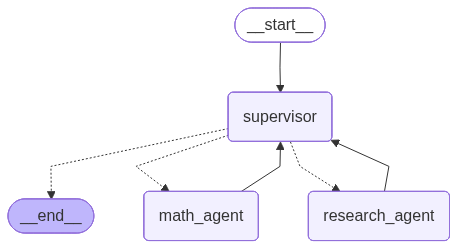

In [2]:
from vision_rag_gpt5 import VisionRAG
from langgraph.prebuilt import create_react_agent
import os
query = "What does rule V.1.4.1 state exactly?"
rag = VisionRAG(model_name="vidore/colqwen2.5-v0.2", device="cuda")

# answer = rag.answer_query(
#                     query=query,
#                     index_name="multimodal_rag_colqwen2.5-v0.2",
#                     k=5,
#                     api_key=os.getenv("OPENAI_API_KEY"),
#                     external_image_path=None,
#                     external_csv_path=None,
#                     prefer_csv_prompt=True,
#                     fallback_input_path="dataset/docs/FSAE_Rules_2024_V1.pdf",
#                     max_completion_tokens=1024,
#                     reasoning="medium",
#                 )
def colpali_rag(query: str):
    """Retrieve the answer from the ColPali RAG."""
    rag = VisionRAG(model_name="vidore/colqwen2.5-v0.2", device="cuda")
    # results = rag.search(query, index_name="multimodal_rag_colqwen2.5-v0.2", k=5)
    # image_parts = [
    #         {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{res.base64}"}}
    #         for res in results
    #     ]
    answer = rag.answer_query(query, index_name="multimodal_rag_colqwen2.5-v0.2", k=15, api_key=os.getenv("OPENAI_API_KEY"), external_image_path=None, external_csv_path=None, prefer_csv_prompt=True, reasoning="medium")
    return answer
# answer = colpali_rag(query, k=5)
rag_agent = create_react_agent(
    model="openai:gpt-5-nano",
    tools=[colpali_rag],
    prompt=(
        "You are a retrieval agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with retrieval-related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="retrieval_agent",
)

In [3]:
from openai import OpenAI
import base64
import os
from pathlib import Path
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
system_prompt = """You are a meticulous vision-language assistant.
Your goal is to describe the provided plot image in such detail that someone
who cannot see it could still fully understand what it shows.

Your description must include:

1. **Overall figure**: type of chart (line, bar, scatter, etc.), title (if readable), 
   and general layout (single panel, multiple subplots, presence of colorbars).

2. **Axes**: 
   - Labels (exact text if legible, else say "unreadable")
   - Units (e.g., "mm", "seconds", "°C") or state "not specified"
   - Axis ranges and tick values (approximate if necessary)
   - Whether axes are linear, logarithmic, categorical, etc.

3. **Data series**:
   - How many series are present
   - Their styles (color, marker, line type)
   - Any labels in the legend (if visible)
   - Description of each series’ trend (e.g., rising, flat, peaks, correlations)

4. **Annotations and extras**:
   - Text labels, arrows, highlighted regions, error bars, shading
   - Gridlines, secondary axes, insets, or unusual features

5. **Trends & insights**:
   - Main relationships between x and y
   - Notable thresholds, turning points, or crossings between series
   - Comparative analysis of series (who dominates where)

6. **Uncertainties & missing info**:
   - If any text, axis labels, ticks, or legend entries are unreadable, state this
   - Mention what information is does not makes sense or is missing.

7. **Conclusions**:
   - all  key takeaways from the plot
   - Avoid speculation beyond the image

Output format:
---
JSON:

---
Report:

"""
def image_to_data_url(path: str) -> str:
    data = Path(path).read_bytes()
    b64 = base64.b64encode(data).decode("utf-8")
    return f"data:image/png;base64,{b64}"
def analyze_image(img_path: str):
    """Analyze the given image in detail."""
    data_url = image_to_data_url(img_path)
    response = client.chat.completions.create(
        model="gpt-5-nano",
        messages=[
            {"role": "system", "content": system_prompt},
            {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": "Please analyze this plot image with the above instructions."},
                        {"type": "image_url", "image_url": {"url": data_url}},
                    ],
                },
        ]
    )
    image_description = response.choices[0].message.content
    return image_description
img_agent = create_react_agent(
    model="openai:gpt-5-nano",
    tools=[analyze_image],
    prompt=(
        "You are an image analysis agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with image analysis-related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="vision_agent",
)

In [8]:
from langgraph_supervisor import create_supervisor
from langchain.chat_models import init_chat_model

supervisor = create_supervisor(
    model=init_chat_model("openai:gpt-5-nano"),
    agents=[img_agent, rag_agent],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- an image analysis agent, helpful for analyzing any image given by the user\n"
        "- a retrieval agent, helpful for retrieving information from the documents\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
    ),
    add_handoff_back_messages=True,
    output_mode="full_history",
).compile()

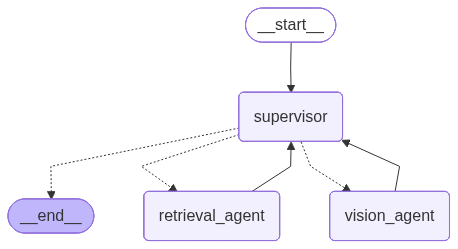

In [5]:
from IPython.display import display, Image

display(Image(supervisor.get_graph().draw_mermaid_png()))

In [14]:
question = """
image_path = "dataset/rule_compliance/rule_functional_performance_qa/images/1.png"
We are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Also attached is an image that shows the results from an FEA simulation performed on the battery structure. The battery structure is made from non-welded 6061-T6 aluminum tubing. Based on the results presented in the image and rule F.3.5.3b in the rule document, can we use the battery structure in the vehicle?  First provide an explanation for your answer (begin it with ‘Explanation:’). Then provide just a yes/no answer (begin it with ‘Answer:’) that summarizes your response.

"""
for chunk in supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                # "content": "What does rule V.1.4.1 state exactly?",
                "content": question
            }
        ]
    },
):
    pretty_print_messages(chunk, last_message=True)

final_message_history = chunk["supervisor"]["messages"]

Update from node supervisor:


================================= Tool Message =================================
Name: transfer_to_retrieval_agent

Successfully transferred to retrieval_agent




Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Update from node retrieval_agent:


================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor


Update from node supervisor:


================================= Tool Message =================================
Name: transfer_to_vision_agent

Successfully transferred to vision_agent


Update from node vision_agent:


================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor


Update from node supervisor:


================================== Ai Message ==================================
Name: supervisor

Explanation: F.3.5.3b specifies material properties for the SES when using non-welded 6061-T6 aluminum tubing (E = 69 GPa, Sy = 240 MPa, Su = 290 MPa). The attached FEA results indicate peak stresses around 220 MPa, which are below the yield and ultimate strengths, and the deflections appe

In [27]:
# question = """
# image_path = "dataset/rule_compliance/rule_functional_performance_qa/images/1.png"
# We are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Also attached is an image that shows the results from an FEA simulation performed on the battery structure. The battery structure is made from non-welded 6061-T6 aluminum tubing. Based on the results presented in the image and rule F.3.5.3b in the rule document, can we use the battery structure in the vehicle?  First provide an explanation for your answer (begin it with ‘Explanation:’). Then provide just a yes/no answer (begin it with ‘Answer:’) that summarizes your response.

# """
question = """
image_path = None
We are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Please list all rules relevant to `Aerodynamic/Aerodynamics`. Answer with only the rule numbers (i.e.: AA.1.1.1) separated by commas and no other words.
"""
message = supervisor.invoke({"messages": [{"role": "user", "content": question}]})
message["messages"][-1].content

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

'T.7.1.1,T.7.1.2,T.7.1.3,T.7.1.4,T.7.1.5,T.7.2.1,T.7.2.2,T.7.2.3,T.7.2.4,T.7.3.1,T.7.3.2,T.7.3.3,T.7.4,T.7.5,T.7.6.1,T.7.6.2,T.7.6.3,T.7.7.1,IN.8.2,IN.8.3,IN.8.4,IN.8.5,IN.9.1,IN.9.2,IN.9.3'

In [28]:
message

{'messages': [HumanMessage(content='\nimage_path = None\nWe are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Please list all rules relevant to `Aerodynamic/Aerodynamics`. Answer with only the rule numbers (i.e.: AA.1.1.1) separated by commas and no other words.\n', additional_kwargs={}, response_metadata={}, id='0ac810c0-404f-42c9-96fe-c278013d6844'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_4zTMwFy65C5LcZhBOEng0IYV', 'function': {'arguments': '{}', 'name': 'transfer_to_retrieval_agent'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 343, 'prompt_tokens': 278, 'total_tokens': 621, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint'

In [10]:
question = """
image_path: dataset/rule_compliance/rule_functional_performance_qa/images/2.png
We are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Also attached is an image that shows the results from an FEA simulation performed on the battery structure. The battery structure is made from non-welded 6061-T6 aluminum tubing. Based on the results presented in the image and rule F.3.5.3b in the rule document, can we use the battery structure in the vehicle? First provide an explanation for your answer (begin it with ‘Explanation:’). Then provide just a yes/no answer (begin it with ‘Answer:’) that summarizes your response.
"""
# question = """
# image_path = None
# We are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Please list all rules relevant to `Aerodynamic/Aerodynamics`. Answer with only the rule numbers (i.e.: AA.1.1.1) separated by commas and no other words.
# """
message = supervisor.invoke({"messages": [{"role": "user", "content": question}]})
message["messages"][-1].content

'Explanation: The image shows peak stress around 260 MPa concentrated at the outer frame and joints, with interior members at lower stress. 6061-T6 aluminum typically yields around 275 MPa. Since the observed peak stress is below yield, it suggests compliance with a yield-based limit in rule F.3.5.3b under the depicted load. However, uncertainties remain (exact stress metric used (von Mises vs other), load case/boundary conditions, required safety factor, fatigue considerations, and the precise wording of the rule). Given these caveats, the result appears compliant based on the presented data, but this is not a definitive endorsement without more details.\n\nAnswer: Yes'

In [11]:
message

{'messages': [HumanMessage(content='\nimage_path: dataset/rule_compliance/rule_functional_performance_qa/images/2.png\nWe are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Also attached is an image that shows the results from an FEA simulation performed on the battery structure. The battery structure is made from non-welded 6061-T6 aluminum tubing. Based on the results presented in the image and rule F.3.5.3b in the rule document, can we use the battery structure in the vehicle? First provide an explanation for your answer (begin it with ‘Explanation:’). Then provide just a yes/no answer (begin it with ‘Answer:’) that summarizes your response.\n', additional_kwargs={}, response_metadata={}, id='914d700e-882d-4cb7-b8e5-2857532b4168'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_1fW5MllS9hsKFebhmY3QEMFL', 'function': {'arguments': '{}', 'name': 'transfer_to_vision_agent'}, 'type': 'function'}], 're

In [12]:
question = """
image_path: dataset/rule_compliance/rule_functional_performance_qa/images/3.png
We are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Also attached is an image that shows information about the riders that can be accommodated in the vehicle. At the top of the image, there is general anthropomorphic information. Below that, there is information about the largest man and smallest woman our vehicle can accommodate. Based on the information presented in the image, does our vehicle comply with rule V.2.1.1 presented in the rule document? First provide an explanation for your answer (begin it with ‘Explanation:’). Then provide just a yes/no answer (begin it with ‘Answer:’) that summarizes your response."""
# question = """
# image_path = None
# We are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Please list all rules relevant to `Aerodynamic/Aerodynamics`. Answer with only the rule numbers (i.e.: AA.1.1.1) separated by commas and no other words.
# """
message = supervisor.invoke({"messages": [{"role": "user", "content": question}]})
message["messages"][-1].content

'Explanation: The image provides explicit anthropometric data for the smallest woman (5th percentile female) and the largest man (95th percentile male), with complete measurements in metric and imperial units. The bottom tables list the exact dimensions for these extremes, illustrating that the cockpit can accommodate occupants across this defined range, which aligns with the general intent of rule V.2.1.1 to accommodate an anthropometric range for occupants.\n\nAnswer: Yes'

In [14]:
message

{'messages': [HumanMessage(content='\nimage_path: dataset/rule_compliance/rule_functional_performance_qa/images/3.png\nWe are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Also attached is an image that shows information about the riders that can be accommodated in the vehicle. At the top of the image, there is general anthropomorphic information. Below that, there is information about the largest man and smallest woman our vehicle can accommodate. Based on the information presented in the image, does our vehicle comply with rule V.2.1.1 presented in the rule document? First provide an explanation for your answer (begin it with ‘Explanation:’). Then provide just a yes/no answer (begin it with ‘Answer:’) that summarizes your response.', additional_kwargs={}, response_metadata={}, id='582c26e9-bef4-4bef-aff5-1725604d2825'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_j13VKMQAz39XBThnQANjDVrs', 'fun

In [15]:
final_message_history

[HumanMessage(content='\nimage_path = "dataset/rule_compliance/rule_functional_performance_qa/images/1.png"\nWe are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Also attached is an image that shows the results from an FEA simulation performed on the battery structure. The battery structure is made from non-welded 6061-T6 aluminum tubing. Based on the results presented in the image and rule F.3.5.3b in the rule document, can we use the battery structure in the vehicle?  First provide an explanation for your answer (begin it with ‘Explanation:’). Then provide just a yes/no answer (begin it with ‘Answer:’) that summarizes your response.\n\n', additional_kwargs={}, response_metadata={}, id='eca2b063-4852-4a2e-8533-1cb59c068597'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_00LD8OJD3SSZBQNrpfoJ3Tie', 'function': {'arguments': '{}', 'name': 'transfer_to_retrieval_agent'}, 'type': 'function'}], 'refusal